# Road Lane Detection — VGG-UNet on TuSimple

Lane detection as **binary image segmentation**: a VGG16-encoder UNet predicts a per-pixel
lane mask from a dashcam frame. Built for Apple Silicon (M1) with PyTorch + MPS.

Pipeline: **data preprocessing → model → training → visualization → evaluation**.

> Run with the `Python (vgg-lanenet)` kernel (the project `.venv`).


## 1. Setup & device

In [1]:
import os, json, glob, random, math, time
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models import vgg16_bn, VGG16_BN_Weights
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| torch", torch.__version__)

Matplotlib is building the font cache; this may take a moment.


Device: mps | torch 2.12.1


## 2. Configuration

In [2]:
class Cfg:
    DATA_ROOT   = "TUSimple"
    TRAIN_DIR   = os.path.join(DATA_ROOT, "train_set")
    TEST_DIR    = os.path.join(DATA_ROOT, "test_set")
    TRAIN_LABELS = ["label_data_0313.json", "label_data_0531.json", "label_data_0601.json"]
    TEST_LABEL   = os.path.join(DATA_ROOT, "test_label.json")  # GT for held-out eval

    IMG_H, IMG_W = 256, 512        # network input size (orig frames are 720x1280)
    LANE_WIDTH   = 8               # px thickness used when rasterizing lane polylines (at orig res)

    BATCH_SIZE   = 8
    EPOCHS       = 5
    LR           = 1e-4
    VAL_FRAC     = 0.1
    # Cap samples for fast iteration on a laptop. Set to None to use the whole set.
    MAX_TRAIN_SAMPLES = 800
    NUM_WORKERS  = 2

    CKPT = "vgg_unet_lanenet.pt"

cfg = Cfg()
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], np.float32)

## 3. Data preprocessing

Each TuSimple label line gives a clip's last frame: `lanes` (x per height) paired with shared
`h_samples` (y). `x == -2` means *no lane at that height*. We rasterize each lane's valid
`(x, y)` points into a polyline to produce a **binary lane mask**, then resize image+mask to the
network resolution.

In [3]:
def load_records(label_dir, label_files):
    recs = []
    for lf in label_files:
        path = os.path.join(label_dir, lf)
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
    return recs

def lane_mask(lanes, h_samples, h, w, thickness):
    """Rasterize lane polylines into a binary mask of size (h, w)."""
    mask = np.zeros((h, w), np.uint8)
    for lane in lanes:
        pts = [(int(x), int(y)) for x, y in zip(lane, h_samples) if x >= 0]
        for (x0, y0), (x1, y1) in zip(pts[:-1], pts[1:]):
            cv2.line(mask, (x0, y0), (x1, y1), 1, thickness)
    return mask

# sanity check on one record
_recs = load_records(cfg.TRAIN_DIR, [cfg.TRAIN_LABELS[0]])
print("train records (file 0):", len(_recs))
_r = _recs[0]
_img = cv2.imread(os.path.join(cfg.TRAIN_DIR, _r["raw_file"]))
_m = lane_mask(_r["lanes"], _r["h_samples"], _img.shape[0], _img.shape[1], cfg.LANE_WIDTH)
print("image:", _img.shape, "| mask lane px:", int(_m.sum()))

train records (file 0): 2858
image: (720, 1280, 3) | mask lane px: 19754


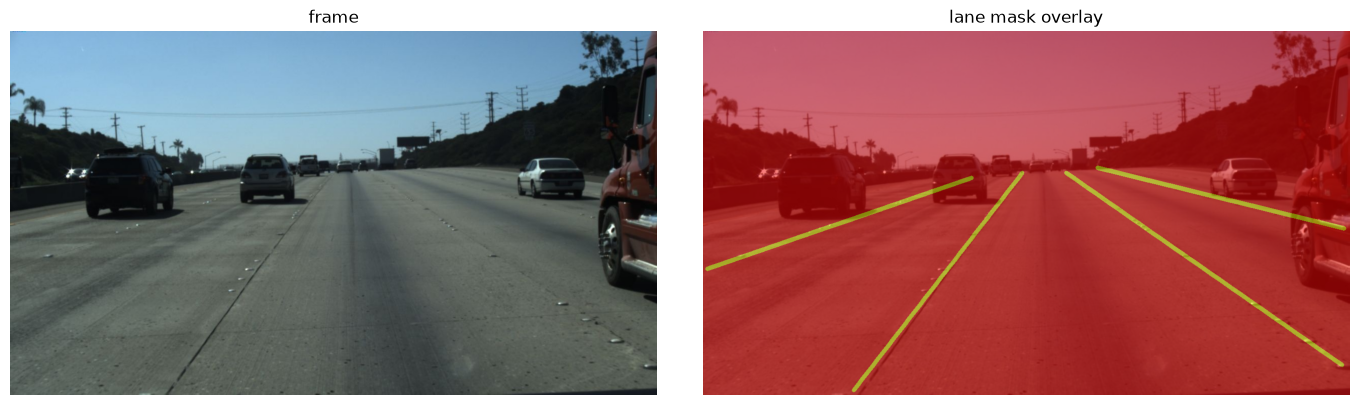

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("frame"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB))
ax[1].imshow(_m, alpha=0.5, cmap="autumn"); ax[1].set_title("lane mask overlay"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 4. Dataset & DataLoaders

In [5]:
class TuSimpleLanes(Dataset):
    def __init__(self, root, records, cfg, train=True):
        self.root, self.records, self.cfg, self.train = root, records, cfg, train

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        r = self.records[i]
        img = cv2.imread(os.path.join(self.root, r["raw_file"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H0, W0 = img.shape[:2]
        mask = lane_mask(r["lanes"], r["h_samples"], H0, W0, self.cfg.LANE_WIDTH)

        img  = cv2.resize(img,  (self.cfg.IMG_W, self.cfg.IMG_H), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.cfg.IMG_W, self.cfg.IMG_H), interpolation=cv2.INTER_NEAREST)

        if self.train and random.random() < 0.5:      # horizontal flip augmentation
            img, mask = img[:, ::-1], mask[:, ::-1]

        img = (img.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        img = torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1)))
        mask = torch.from_numpy(np.ascontiguousarray(mask)).float().unsqueeze(0)
        return img, mask


records = load_records(cfg.TRAIN_DIR, cfg.TRAIN_LABELS)
random.shuffle(records)
if cfg.MAX_TRAIN_SAMPLES:
    records = records[:cfg.MAX_TRAIN_SAMPLES]

n_val = int(len(records) * cfg.VAL_FRAC)
val_recs, train_recs = records[:n_val], records[n_val:]

train_ds = TuSimpleLanes(cfg.TRAIN_DIR, train_recs, cfg, train=True)
val_ds   = TuSimpleLanes(cfg.TRAIN_DIR, val_recs,   cfg, train=False)

train_dl = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                      num_workers=cfg.NUM_WORKERS, drop_last=True)
val_dl   = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                      num_workers=cfg.NUM_WORKERS)
print(f"train {len(train_ds)} | val {len(val_ds)}")
xb, yb = next(iter(train_dl))
print("batch:", xb.shape, yb.shape, "| mask range", float(yb.min()), float(yb.max()))

train 720 | val 80


Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=106, pipe_handle=120)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/harshwadhawe/miniconda3/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/harshwadhawe/miniconda3/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'TuSimpleLanes' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


BrokenPipeError: [Errno 32] Broken pipe

## 5. VGG-UNet model

VGG16-BN (ImageNet-pretrained) is the encoder; feature maps before each max-pool feed UNet skip
connections into a mirrored decoder. Output is a single-channel logit map at input resolution.

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),          nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class VGGUNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = VGG16_BN_Weights.DEFAULT if pretrained else None
        feats = vgg16_bn(weights=weights).features
        # split at max-pool boundaries -> skip feature maps of 64,128,256,512,512 channels
        self.enc1 = feats[0:6]    # 64,  /1
        self.enc2 = feats[6:13]   # 128, /2
        self.enc3 = feats[13:23]  # 256, /4
        self.enc4 = feats[23:33]  # 512, /8
        self.enc5 = feats[33:43]  # 512, /16 (bottleneck)

        self.dec4 = DecoderBlock(512, 512, 256)
        self.dec3 = DecoderBlock(256, 256, 128)
        self.dec2 = DecoderBlock(128, 128, 64)
        self.dec1 = DecoderBlock(64, 64, 32)
        self.head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.enc5(s4)
        d  = self.dec4(b, s4)
        d  = self.dec3(d, s3)
        d  = self.dec2(d, s2)
        d  = self.dec1(d, s1)
        return self.head(d)


model = VGGUNet(pretrained=True).to(device)
with torch.no_grad():
    out = model(xb.to(device))
print("output:", out.shape, "| params (M):", sum(p.numel() for p in model.parameters())/1e6)

## 6. Training

Lane pixels are sparse, so we combine `BCEWithLogitsLoss` (with positive-class weighting) and a
**Dice loss** for overlap. We track validation Dice/IoU and checkpoint the best model.

In [ ]:
def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2 * (p * target).sum(dim=(1, 2, 3)) + eps
    den = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + eps
    return (1 - num / den).mean()

bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0], device=device))

def criterion(logits, target):
    return bce(logits, target) + dice_loss(logits, target)

@torch.no_grad()
def evaluate(model, dl, thr=0.5):
    model.eval()
    inter = union = dice_n = dice_d = 0.0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        p = (torch.sigmoid(model(x)) > thr).float()
        inter  += (p * y).sum().item()
        union  += ((p + y) >= 1).float().sum().item()
        dice_n += 2 * (p * y).sum().item()
        dice_d += (p.sum() + y.sum()).item()
    iou  = inter / (union + 1e-6)
    dice = dice_n / (dice_d + 1e-6)
    return iou, dice

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR)
history = {"train_loss": [], "val_iou": [], "val_dice": []}
best_dice = 0.0

for epoch in range(1, cfg.EPOCHS + 1):
    model.train()
    running = 0.0
    pbar = tqdm(train_dl, desc=f"epoch {epoch}/{cfg.EPOCHS}")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running / len(train_dl)
    val_iou, val_dice = evaluate(model, val_dl)
    history["train_loss"].append(train_loss)
    history["val_iou"].append(val_iou); history["val_dice"].append(val_dice)
    print(f"epoch {epoch}: loss {train_loss:.4f} | val IoU {val_iou:.4f} | val Dice {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), cfg.CKPT)
        print(f"  ✓ saved {cfg.CKPT} (Dice {best_dice:.4f})")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], marker="o"); ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history["val_iou"], marker="o", label="IoU")
ax[1].plot(history["val_dice"], marker="o", label="Dice")
ax[1].set_title("validation"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Result visualization

In [ ]:
def denorm(img_t):
    img = img_t.cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

@torch.no_grad()
def show_predictions(model, ds, n=4, thr=0.5):
    model.eval()
    idxs = random.sample(range(len(ds)), n)
    fig, ax = plt.subplots(n, 3, figsize=(15, 4 * n))
    for row, i in enumerate(idxs):
        x, y = ds[i]
        pred = torch.sigmoid(model(x.unsqueeze(0).to(device)))[0, 0].cpu().numpy()
        img = denorm(x)
        ax[row, 0].imshow(img); ax[row, 0].set_title("input"); ax[row, 0].axis("off")
        ax[row, 1].imshow(img); ax[row, 1].imshow(y[0], alpha=0.5, cmap="autumn")
        ax[row, 1].set_title("ground truth"); ax[row, 1].axis("off")
        ax[row, 2].imshow(img); ax[row, 2].imshow(pred > thr, alpha=0.5, cmap="autumn")
        ax[row, 2].set_title("prediction"); ax[row, 2].axis("off")
    plt.tight_layout(); plt.show()

# load best checkpoint if available
if os.path.exists(cfg.CKPT):
    model.load_state_dict(torch.load(cfg.CKPT, map_location=device))
show_predictions(model, val_ds, n=4)

## 8. Evaluation on the held-out test set

The test split ships with its own ground-truth labels and clips. We score segmentation IoU/Dice
on a sample of it.

In [ ]:
test_recs = load_records(cfg.DATA_ROOT, ["test_label.json"])
random.shuffle(test_recs)
test_recs = test_recs[:200]   # sample for a quick laptop-friendly estimate

# raw_file paths are relative to the test_set folder
test_ds = TuSimpleLanes(cfg.TEST_DIR, test_recs, cfg, train=False)
test_dl = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)

test_iou, test_dice = evaluate(model, test_dl)
print(f"TEST  IoU {test_iou:.4f} | Dice {test_dice:.4f}  (n={len(test_ds)})")
show_predictions(model, test_ds, n=3)

## Notes & next steps

- **Speed:** `Cfg.MAX_TRAIN_SAMPLES` caps the training set for fast iteration — set it to `None`
  and raise `EPOCHS` to train on all ~3.6k frames.
- This treats lanes as one binary class. For TuSimple-style scoring (per-lane point accuracy) or
  lane instance separation, extend the head to multi-class / embedding (LaneNet) outputs.
- MPS has no AMP; if memory is tight, lower `BATCH_SIZE` or `IMG_W/IMG_H`.
